In [10]:
import numpy as np
import polars as pl

In [2]:
# construindo o dataframe
data = {
    'age': [22, 25, 32, 19, 17, 18, 45, 55, 45, 70],
    'income': [2500, 3100, 1800, 1450, 5000, 10000, 7500, 9500, 16000, 18000],
    'sex': ['M', 'F', 'M', 'F', 'M', 'M', 'M', 'F', 'F', 'M'],
    'city': ['SP', 'MG', 'BA', 'CE', 'SP', 'SP', 'MG', 'SP', 'RJ', 'RJ']
}

df = pl.DataFrame(data)

In [3]:
print(df)

shape: (10, 4)
┌─────┬────────┬─────┬──────┐
│ age ┆ income ┆ sex ┆ city │
│ --- ┆ ---    ┆ --- ┆ ---  │
│ i64 ┆ i64    ┆ str ┆ str  │
╞═════╪════════╪═════╪══════╡
│ 22  ┆ 2500   ┆ M   ┆ SP   │
│ 25  ┆ 3100   ┆ F   ┆ MG   │
│ 32  ┆ 1800   ┆ M   ┆ BA   │
│ 19  ┆ 1450   ┆ F   ┆ CE   │
│ 17  ┆ 5000   ┆ M   ┆ SP   │
│ 18  ┆ 10000  ┆ M   ┆ SP   │
│ 45  ┆ 7500   ┆ M   ┆ MG   │
│ 55  ┆ 9500   ┆ F   ┆ SP   │
│ 45  ┆ 16000  ┆ F   ┆ RJ   │
│ 70  ┆ 18000  ┆ M   ┆ RJ   │
└─────┴────────┴─────┴──────┘


## Como alterar apenas uma(s) coluna(s) com algumas condições 
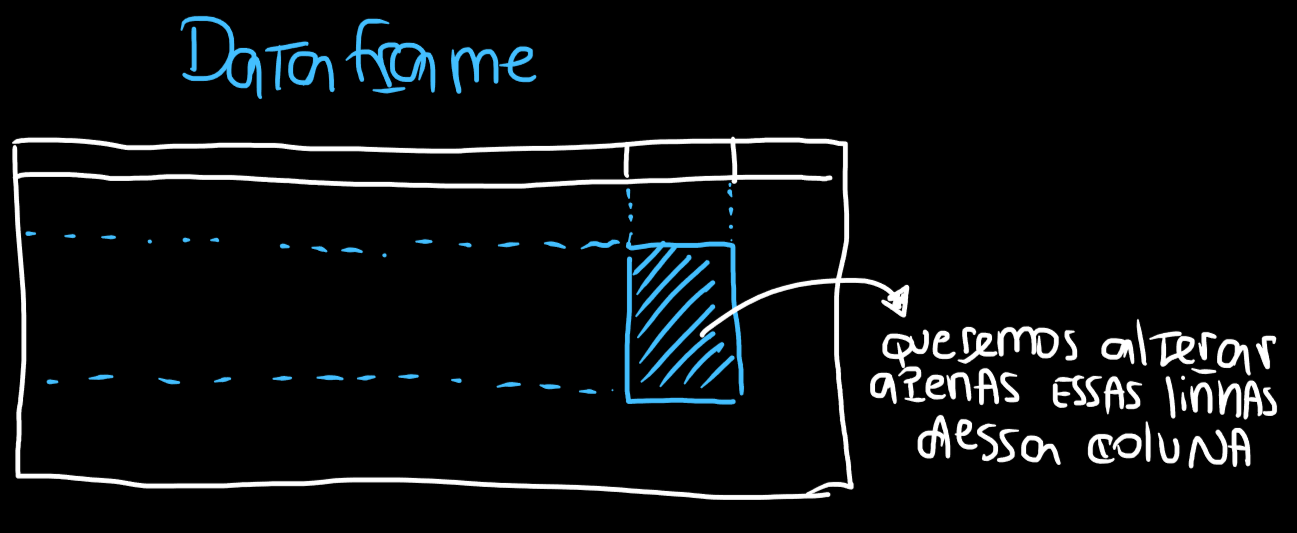

No polars faça o seguinte:

In [7]:
mask = (pl.col('age') < 55) & (pl.col('sex') == 'F')
df.with_columns(
    pl.when(mask)
    .then(pl.lit('PA'))
    .otherwise(pl.col('city'))
    .alias('city')
)

age,income,sex,city
i64,i64,str,str
22,2500,"""M""","""SP"""
25,3100,"""F""","""PA"""
32,1800,"""M""","""BA"""
19,1450,"""F""","""PA"""
17,5000,"""M""","""SP"""
18,10000,"""M""","""SP"""
45,7500,"""M""","""MG"""
55,9500,"""F""","""SP"""
45,16000,"""F""","""PA"""


# Como passar funções em colunas

In [7]:
# existem 2 tipos de funções, funções internas e funções externas
# funções internas usam lógica já existente
df.with_columns(
    new_col=(pl.col('income') * pl.col('age'))
)

age,income,sex,city,new_col
i64,i64,str,str,i64
22,2500,"""M""","""SP""",55000
25,3100,"""F""","""MG""",77500
32,1800,"""M""","""BA""",57600
19,1450,"""F""","""CE""",27550
17,5000,"""M""","""SP""",85000
18,10000,"""M""","""SP""",180000
45,7500,"""M""","""MG""",337500
55,9500,"""F""","""SP""",522500
45,16000,"""F""","""RJ""",720000


In [15]:
df.with_columns(
    new_col=(pl.col('city').str.to_lowercase())
)

age,income,sex,city,age_log,new_col
i64,i64,str,str,f64,str
22,2500,"""M""","""SP""",3.135494,"""sp"""
25,3100,"""F""","""MG""",3.258097,"""mg"""
32,1800,"""M""","""BA""",3.496508,"""ba"""
19,1450,"""F""","""CE""",2.995732,"""ce"""
17,5000,"""M""","""SP""",2.890372,"""sp"""
18,10000,"""M""","""SP""",2.944439,"""sp"""
45,7500,"""M""","""MG""",3.828641,"""mg"""
55,9500,"""F""","""SP""",4.025352,"""sp"""
45,16000,"""F""","""RJ""",3.828641,"""rj"""


In [16]:
# isso é mais performatico do que passar a função (com def)
df.with_columns(
    age_log=pl.col("age").map_batches(
        lambda s: np.log1p(s.to_numpy()),
        return_dtype=pl.Float64,
    )
)

age,income,sex,city,age_log
i64,i64,str,str,f64
22,2500,"""M""","""SP""",3.135494
25,3100,"""F""","""MG""",3.258097
32,1800,"""M""","""BA""",3.496508
19,1450,"""F""","""CE""",2.995732
17,5000,"""M""","""SP""",2.890372
18,10000,"""M""","""SP""",2.944439
45,7500,"""M""","""MG""",3.828641
55,9500,"""F""","""SP""",4.025352
45,16000,"""F""","""RJ""",3.828641


In [18]:
# funções externas são criadas e depois passadas
def foobar(x) -> str:
    return x + 1000


df.with_columns(
    new_col=pl.col("income").map_elements(
        lambda x: foobar(x),
        return_dtype=pl.Float64,
    )
)

age,income,sex,city,age_log,new_col
i64,i64,str,str,f64,f64
22,2500,"""M""","""SP""",3.135494,3500.0
25,3100,"""F""","""MG""",3.258097,4100.0
32,1800,"""M""","""BA""",3.496508,2800.0
19,1450,"""F""","""CE""",2.995732,2450.0
17,5000,"""M""","""SP""",2.890372,6000.0
18,10000,"""M""","""SP""",2.944439,11000.0
45,7500,"""M""","""MG""",3.828641,8500.0
55,9500,"""F""","""SP""",4.025352,10500.0
45,16000,"""F""","""RJ""",3.828641,17000.0


In [19]:
def foobar(income, age) -> str:
    return income + age + 1000

df.with_columns(
    new_col=pl.struct(['income', 'age']).map_elements(
        lambda row: foobar(row['income'], row['age']),
        return_dtype=pl.Float64,
    )
)

age,income,sex,city,age_log,new_col
i64,i64,str,str,f64,f64
22,2500,"""M""","""SP""",3.135494,3522.0
25,3100,"""F""","""MG""",3.258097,4125.0
32,1800,"""M""","""BA""",3.496508,2832.0
19,1450,"""F""","""CE""",2.995732,2469.0
17,5000,"""M""","""SP""",2.890372,6017.0
18,10000,"""M""","""SP""",2.944439,11018.0
45,7500,"""M""","""MG""",3.828641,8545.0
55,9500,"""F""","""SP""",4.025352,10555.0
45,16000,"""F""","""RJ""",3.828641,17045.0


# Como usar uma função de agregação para criar uma coluna nova

In [23]:
# precisamos usar OVER
df.with_columns(
    [
        pl.col("income")
        .mean()
        .over(["city", "sex"])
        .alias("income_mean_city_sex"),

        pl.col("income")
        .std()
        .over(["city", "sex"])
        .alias("income_std_city_sex"),
    ]
)

age,income,sex,city,age_log,income_mean_city_sex,income_std_city_sex
i64,i64,str,str,f64,f64,f64
22,2500,"""M""","""SP""",3.135494,5833.333333,3818.813079
25,3100,"""F""","""MG""",3.258097,3100.0,null
32,1800,"""M""","""BA""",3.496508,1800.0,null
19,1450,"""F""","""CE""",2.995732,1450.0,null
17,5000,"""M""","""SP""",2.890372,5833.333333,3818.813079
18,10000,"""M""","""SP""",2.944439,5833.333333,3818.813079
45,7500,"""M""","""MG""",3.828641,7500.0,null
55,9500,"""F""","""SP""",4.025352,9500.0,null
45,16000,"""F""","""RJ""",3.828641,16000.0,null


# Pivot

In [25]:
df.pivot(
    on="sex",
    index="city",
    values="income",
    aggregate_function="mean"
)

city,M,F
str,f64,f64
"""SP""",5833.333333,9500.0
"""MG""",7500.0,3100.0
"""BA""",1800.0,null
"""CE""",null,1450.0
"""RJ""",18000.0,16000.0


# Melt

In [27]:
# isso é muito usado para gráficos
df.unpivot(
    index=["age", "city", "sex"],
    on=["income", "age_log"]
)

age,city,sex,variable,value
i64,str,str,str,f64
22,"""SP""","""M""","""income""",2500.0
25,"""MG""","""F""","""income""",3100.0
32,"""BA""","""M""","""income""",1800.0
19,"""CE""","""F""","""income""",1450.0
17,"""SP""","""M""","""income""",5000.0
…,…,…,…,…
18,"""SP""","""M""","""age_log""",2.944439
45,"""MG""","""M""","""age_log""",3.828641
55,"""SP""","""F""","""age_log""",4.025352


# Crosstab

In [28]:
# O polars não possui um cross table nativo, por isso utilizamos pivot
(
    df
    .group_by(["city", "sex"])
    .len()
    .pivot(
        on="sex",
        index="city",
        values="len"
    )
    .fill_null(0)
    .with_columns(
        (
            pl.sum_horizontal(pl.exclude("city"))
        ).alias("total")
    )
    .with_columns(
        [
            (pl.col("F") / pl.col("total")).alias("F_pct"),
            (pl.col("M") / pl.col("total")).alias("M_pct"),
        ]
    )
)

city,F,M,total,F_pct,M_pct
str,u32,u32,u32,f64,f64
"""MG""",1,1,2,0.5,0.5
"""BA""",0,1,1,0.0,1.0
"""RJ""",1,1,2,0.5,0.5
"""SP""",1,3,4,0.25,0.75
"""CE""",1,0,1,1.0,0.0
